# Notebook 03 — Method Validation & Comparison

Four targeted analyses validating the factor-trace method toward publication:

1. **NMF Factor Stability** — reproducibility of the factorization across random seeds
2. **Comparative Ablation Study** — algo_top vs magnitude / Taylor / random baselines
3. **Causal Circuit Ablation** — class-specific dfs_trace → percentile ablation → selective accuracy drop
4. **Gradient Attribution Comparison** — NMF pixel patterns vs saliency and integrated gradients
5. **Cross-Class Circuit Specificity** — which digit circuits overlap?

Model: `SimpleMLP 784→40→20→10` on MNIST digit classification (5 seeds).

In [34]:
import sys, os, pickle, copy
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from scipy.integrate import trapezoid
from scipy.stats import spearmanr, wilcoxon
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import warnings

from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

from src import (
    load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs,
    full_nmf_pipeline,
    bft,
    assign_factors_to_classes, path_from_child, extract_importance_scores,
    magnitude_scores, act_magnitude_scores, taylor_scores,
    ablate_model, per_class_accuracy,
    run_ablation_sweep,
)


## Config

In [35]:
# ── experiment seeds ─────────────────────────────────────────────────────────
SEED_DIRS = [f'../experiments/mnist_digit_mlp_40_20_seed{s}' for s in range(5)]

N_CLASSES        = 10
ABLATION_FRACS   = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_RANDOM_REPEATS = 10    # draws to average for random baseline (§2)
PERCENTILES      = [50, 75, 90, 95, 99]  # importance thresholds for §3
N_STAB_SEEDS     = 10   # NMF random seeds for stability analysis (§1)
N_PER_CLASS      = 200  # samples per class for §1 / §3 layer_inputs
STIM_THRESH      = 0.1

# bft parameters
K_TRACE    = [5,  5,  10]   # NMF rank per layer (L1→L2→output)
K_TRACE_S3 = [5,  5,  3]    # smaller output rank for class-specific bft (§3)
K_TRACE_S2 = K_TRACE_S3  # backward-compat alias
N_BRANCHES = [1,  1,  10]   # 10 branches at output, then top-1 inward
STIM_THRESHOLD = 0.1

# ── cache directories ─────────────────────────────────────────────────────
# CACHE_ABL: comparative ablation sweep (§2)
# CACHE_VAL: NMF stability, causal ablation, attribution (§1 / §3 / §4 / §5)
CACHE_ABL = '../experiments/ablation_cache'
CACHE_VAL = '../experiments/05_cache'
CACHE_DIR = CACHE_VAL  # alias used by §1/§3/§4/§5 cells
os.makedirs(CACHE_ABL, exist_ok=True)
os.makedirs(CACHE_VAL, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)


device: cpu


In [36]:
import os as _os
FIG_ABL = _os.path.join('..', 'figs', '03_ablation')
_os.makedirs(FIG_ABL, exist_ok=True)
print('fig dir:', FIG_ABL)


fig dir: ../figs/03_ablation


In [37]:
# ── Load canonical model (seed 0) and shared test dataset ──────────────────────
model0, config0 = load_experiment(SEED_DIRS[0], device=DEVICE)
model0.eval()

test_ds     = datasets.MNIST('../data/', train=False, download=True, transform=ToTensor())
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

print(config0['description'])
print(f'Test set: {len(test_ds)} samples')


SimpleMLP 784->40->20->10 on MNIST digit classification, seed 0
Test set: 10000 samples


In [38]:
# ── Collect layer inputs for seed 0 (reused across sections) ───────────────────
_p = os.path.join(CACHE_VAL, 'layer_inputs_seed0.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        data0 = pickle.load(f)
    print('Loaded from cache')
else:
    data0 = collect_layer_inputs(model0, test_ds, label_transform=None,
                                  n_per_class=N_PER_CLASS, device=DEVICE)
    with open(_p, 'wb') as f:
        pickle.dump(data0, f)
    print('Collected and cached')

layer_inputs0 = data0['layer_inputs']
all_targets0  = data0['targets']
all_images0   = data0['images']
N_SAMP        = len(all_targets0)
layer_names   = {0: 'L1 (784→40)', 1: 'L2 (40→20)', 2: 'Out (20→10)'}
print(f'{N_SAMP} samples | layer shapes: {[x.shape for x in layer_inputs0]}')


Loaded from cache
1881 samples | layer shapes: [(1881, 784), (1881, 40), (1881, 20)]


---
## Section 1: NMF Factor Stability

Run `full_nmf_pipeline` 10 times on the **same** joint-arbor matrices (from a single `dfs_trace`)
with different `random_state` values.  
Use Hungarian matching to compute the best-match cosine similarity between every seed pair
(45 off-diagonal pairs per layer).  
High similarity → the factorization is reproducible, not an artifact of initialisation.

In [39]:
def factor_cosine_sim(W1, W2):
    """(K, K) cosine similarity matrix between columns of W1 and W2."""
    W1 = W1 / (np.linalg.norm(W1, axis=0, keepdims=True) + 1e-12)
    W2 = W2 / (np.linalg.norm(W2, axis=0, keepdims=True) + 1e-12)
    return W1.T @ W2

def best_match_sim(W1, W2):
    """Scalar: Hungarian-matched mean cosine similarity."""
    sim = factor_cosine_sim(W1, W2)
    row, col = linear_sum_assignment(-sim)
    return float(sim[row, col].mean())

In [40]:
# ── Run bft (n_branches=1, single chain) to obtain joint_arbors per layer ──────
_p = os.path.join(CACHE_DIR, 'bft_seed0.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        trace0 = pickle.load(f)
    print('Loaded bft trace from cache')
else:
    _root = bft(model0, layer_inputs0, k_max=K_TRACE, n_branches=1, stimulus_threshold=STIM_THRESH)
    def _spine(root):
        chain = [root]
        node = root
        while node['children']:
            node = node['children'][0]
            chain.append(node)
        return chain
    trace0 = _spine(_root)
    with open(_p, 'wb') as f:
        pickle.dump(trace0, f)
    print('Computed and cached bft trace')

# trace0 is ordered last-layer-first: [output(l2), L2(l1), L1(l0)]
joint_arbors = {res['layer_idx']: res['joint_arbor'] for res in trace0}
for l_idx, ja in sorted(joint_arbors.items()):
    print(f'  Layer {l_idx}: joint_arbor {ja.shape}')


Loaded dfs_trace from cache
  Layer 0: joint_arbor (1881, 31360)
  Layer 1: joint_arbor (1881, 800)
  Layer 2: joint_arbor (1881, 200)


In [41]:
# ── Multi-seed NMF stability ────────────────────────────────────────────────────
# NOTE: L1 layer (31 360 features) takes ~15-30 s per call → ~10 min total, cached.
_p = os.path.join(CACHE_DIR, 'stability.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        stab = pickle.load(f)
    print('Loaded stability data from cache')
else:
    print('Computing NMF stability (10 seeds × 3 layers) — ~10 min…')
    K_per_layer = {0: K_TRACE[0], 1: K_TRACE[1], 2: K_TRACE[2]}
    stab = {}
    for l_idx, ja in sorted(joint_arbors.items()):
        K = K_per_layer[l_idx]
        print(f'  Layer {l_idx} (K={K}, shape {ja.shape})…')
        factors = []
        for seed in range(N_STAB_SEEDS):
            img_f, neu_f, lams = full_nmf_pipeline(ja, K, random_state=seed, max_iter=5000, init='random')
            factors.append({'img': img_f, 'neu': neu_f})
        n = N_STAB_SEEDS
        sim_img = np.zeros((n, n))
        sim_neu = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                sim_img[i, j] = best_match_sim(factors[i]['img'], factors[j]['img'])
                sim_neu[i, j] = best_match_sim(factors[i]['neu'], factors[j]['neu'])
        stab[l_idx] = {'sim_img': sim_img, 'sim_neu': sim_neu}
        offdiag = sim_img[~np.eye(n, dtype=bool)]
        print(f'    img off-diag mean: {offdiag.mean():.3f}')
    with open(_p, 'wb') as f:
        pickle.dump(stab, f)
    print('Saved.')

Loaded stability data from cache


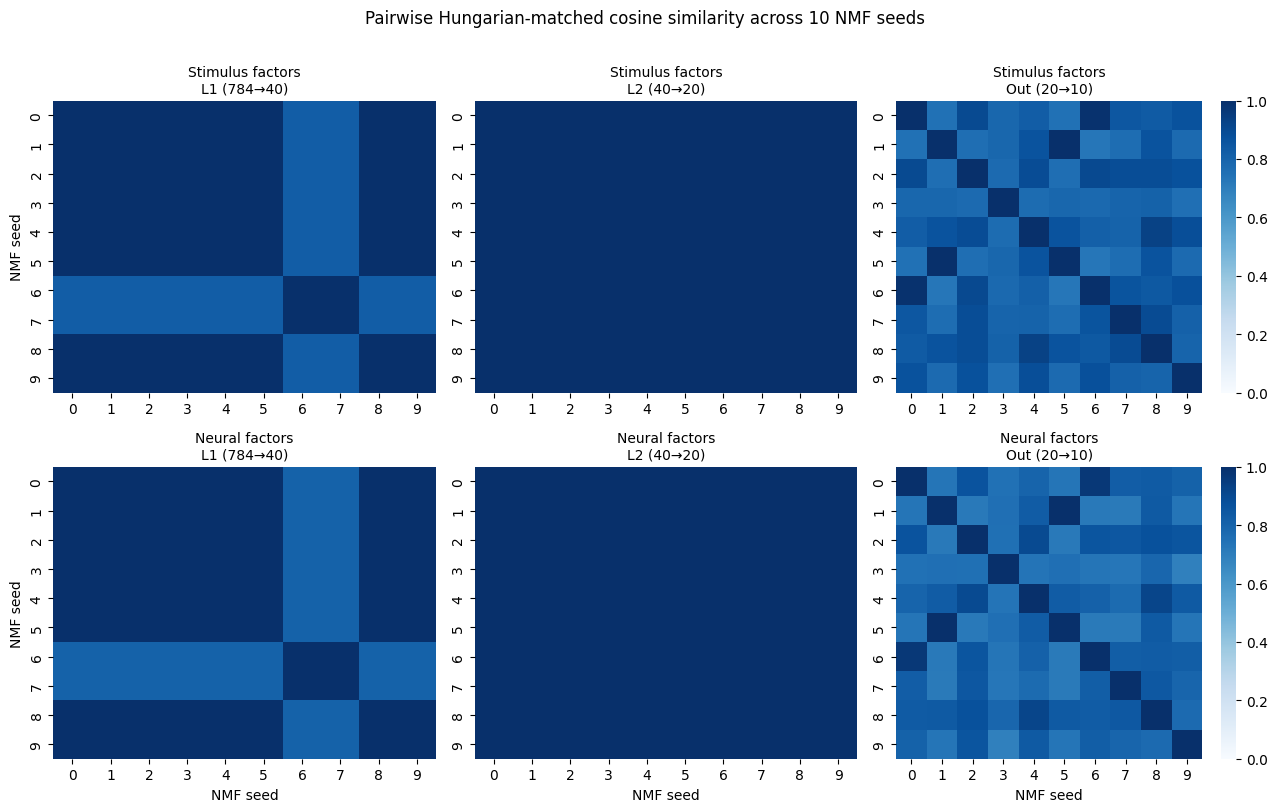

In [42]:
# ── Plot: stability heatmaps ────────────────────────────────────────────────────
layer_names = {0: 'L1 (784→40)', 1: 'L2 (40→20)', 2: 'Out (20→10)'}
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for col, l_idx in enumerate(sorted(stab)):
    for row, (key, label) in enumerate([('sim_img', 'Stimulus factors'), ('sim_neu', 'Neural factors')]):
        ax = axes[row, col]
        sns.heatmap(stab[l_idx][key], ax=ax, vmin=0, vmax=1, cmap='Blues',
                    annot=False, cbar=(col == 2))
        ax.set_title(f'{label}\n{layer_names[l_idx]}', fontsize=10)
        if col == 0: ax.set_ylabel('NMF seed')
        if row == 1: ax.set_xlabel('NMF seed')
plt.suptitle('Pairwise Hungarian-matched cosine similarity across 10 NMF seeds', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_ABL, 'fig1a_stability_heatmaps.pdf'), bbox_inches='tight')
plt.show()


Stimulus factors:
  L1 (784→40): 0.938 ± 0.083  Wilcoxon vs 0.90: p=0.0000  (n=90)
  L2 (40→20): 1.000 ± 0.000  Wilcoxon vs 0.90: p=0.0000  (n=90)
  Out (20→10): 0.829 ± 0.065  Wilcoxon vs 0.90: p=1.0000  (n=90)

Neural factors:
  L1 (784→40): 0.931 ± 0.093  Wilcoxon vs 0.90: p=0.0000  (n=90)
  L2 (40→20): 1.000 ± 0.000  Wilcoxon vs 0.90: p=0.0000  (n=90)
  Out (20→10): 0.799 ± 0.069  Wilcoxon vs 0.90: p=1.0000  (n=90)


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_7908/1880098319.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=tick_labels, patch_artist=True)
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_7908/1880098319.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=tick_labels, patch_artist=True)


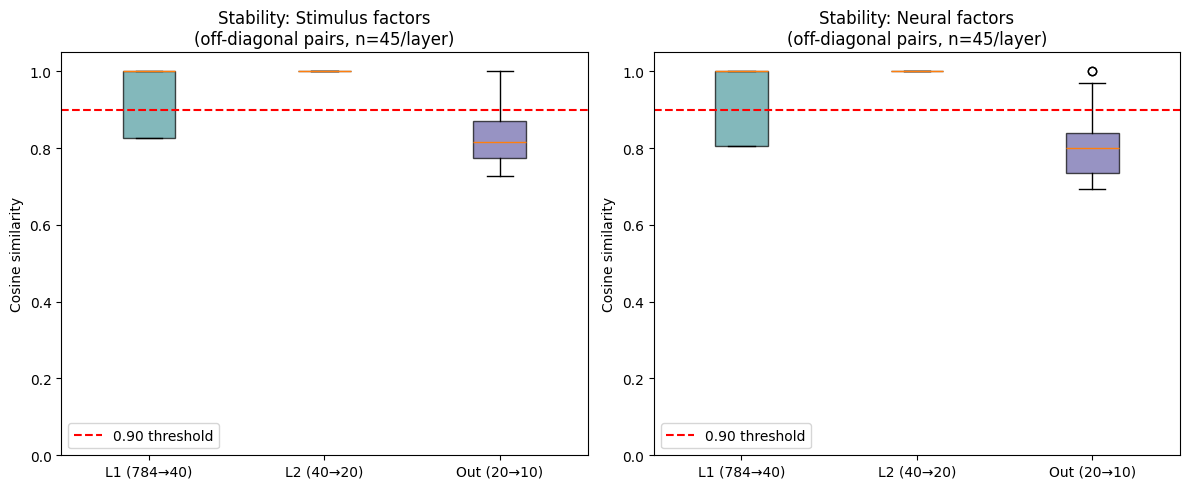

In [43]:
# ── Plot: boxplots + Wilcoxon test ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
n = N_STAB_SEEDS
mask_offdiag_stab = ~np.eye(n, dtype=bool)

for ax_i, (key, label) in enumerate([('sim_img', 'Stimulus factors'), ('sim_neu', 'Neural factors')]):
    ax = axes[ax_i]
    data_bp, tick_labels = [], []
    print(f'\n{label}:')
    for l_idx in sorted(stab):
        vals = stab[l_idx][key][mask_offdiag_stab]
        data_bp.append(vals)
        tick_labels.append(layer_names[l_idx])
        stat, pval = wilcoxon(vals - 0.90, alternative='greater')
        print(f'  {layer_names[l_idx]}: {vals.mean():.3f} ± {vals.std():.3f}  '
              f'Wilcoxon vs 0.90: p={pval:.4f}  (n={len(vals)})')

    bp = ax.boxplot(data_bp, labels=tick_labels, patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#4e9a9e', '#e08550', '#6b66aa']):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(0.90, color='red', linestyle='--', label='0.90 threshold')
    ax.set_ylim(0, 1.05); ax.set_ylabel('Cosine similarity')
    ax.set_title(f'Stability: {label}\n(off-diagonal pairs, n=45/layer)')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_ABL, 'fig1b_stability_boxplots.pdf'), bbox_inches='tight')
plt.show()

---
## Section 2: Comparative Ablation Study

For each seed, run `tree_trace` and extract per-weight importance scores for six methods:
`algo_top`, `algo_bottom`, magnitude, activation-weighted magnitude, Taylor, and random.  
Ablate increasing fractions (5–50 %) of weights ranked by each method and measure
per-class accuracy.  Lower AUC under the accuracy-vs-fraction curve = steeper degradation
= the method identified more critical weights.

## Main loop — collect ablation results across seeds

In [44]:
METHODS = ['algo_top', 'algo_bottom', 'magnitude', 'act_magnitude', 'taylor', 'random']

# all_results[seed_idx][method][class_d][fraction] = accuracy
all_results = []

for seed_idx, exp_dir in enumerate(SEED_DIRS):
    cache_path = os.path.join(CACHE_ABL, f'seed{seed_idx}.pkl')

    # ── load from cache if available ──────────────────────────────────────────
    if os.path.exists(cache_path):
        print(f'[seed {seed_idx}] loading from cache: {cache_path}')
        with open(cache_path, 'rb') as f:
            all_results.append(pickle.load(f))
        continue

    if not os.path.isdir(exp_dir):
        print(f'[skip] {exp_dir} not found')
        all_results.append(None)
        continue

    print(f'\n=== seed {seed_idx} ({exp_dir}) ===')
    model, config = load_experiment(exp_dir, device=DEVICE)
    label_transform = get_transform(config.get('label_transform'))
    _, test_loader = get_loaders_from_config(config)

    layer_data = collect_layer_inputs(
        model, test_loader.dataset,
        label_transform=label_transform,
        n_per_class=None, device=DEVICE,
    )
    layer_inputs = layer_data['layer_inputs']
    all_targets  = layer_data['targets']

    # ── factor trace: one tree with 10 branches at the output layer ──
    print('  running bft …')
    root = bft(model, layer_inputs, k_max=K_TRACE, n_branches=N_BRANCHES,
                stimulus_threshold=STIM_THRESHOLD)
    class_to_child = assign_factors_to_classes(root, all_targets, N_CLASSES)

    # per-class algo importance scores
    algo_scores = {}
    for d in range(N_CLASSES):
        path = path_from_child(root, class_to_child[d])
        algo_scores[d] = extract_importance_scores(path)

    # ── baseline scores (class-agnostic; same ranking for every class) ──
    mag_sc  = magnitude_scores(model)
    amag_sc = act_magnitude_scores(model, layer_inputs)

    seed_results = {m: {} for m in METHODS}

    for d in range(N_CLASSES):
        print(f'  class {d}', end=' ', flush=True)

        tay_sc = taylor_scores(model, test_loader, label_transform, DEVICE, d)

        score_map = {
            'algo_top':      algo_scores[d],
            'algo_bottom':   algo_scores[d],
            'magnitude':     mag_sc,
            'act_magnitude': amag_sc,
            'taylor':        tay_sc,
            'random':        mag_sc,   # scores irrelevant for random method
        }

        for method in METHODS:
            seed_results[method][d] = run_ablation_sweep(
                model, score_map[method], ABLATION_FRACS,
                test_loader, label_transform, DEVICE,
                method=method,
                n_random_repeats=N_RANDOM_REPEATS,
            )

        print('done')

    # ── save to cache ─────────────────────────────────────────────────────────
    with open(cache_path, 'wb') as f:
        pickle.dump(seed_results, f)
    print(f'  → cached to {cache_path}')

    all_results.append(seed_results)

print('\nDone.')


[seed 0] loading from cache: ../experiments/ablation_cache/seed0.pkl
[seed 1] loading from cache: ../experiments/ablation_cache/seed1.pkl
[seed 2] loading from cache: ../experiments/ablation_cache/seed2.pkl
[seed 3] loading from cache: ../experiments/ablation_cache/seed3.pkl
[seed 4] loading from cache: ../experiments/ablation_cache/seed4.pkl

Done.


## Per-class accuracy vs ablation fraction

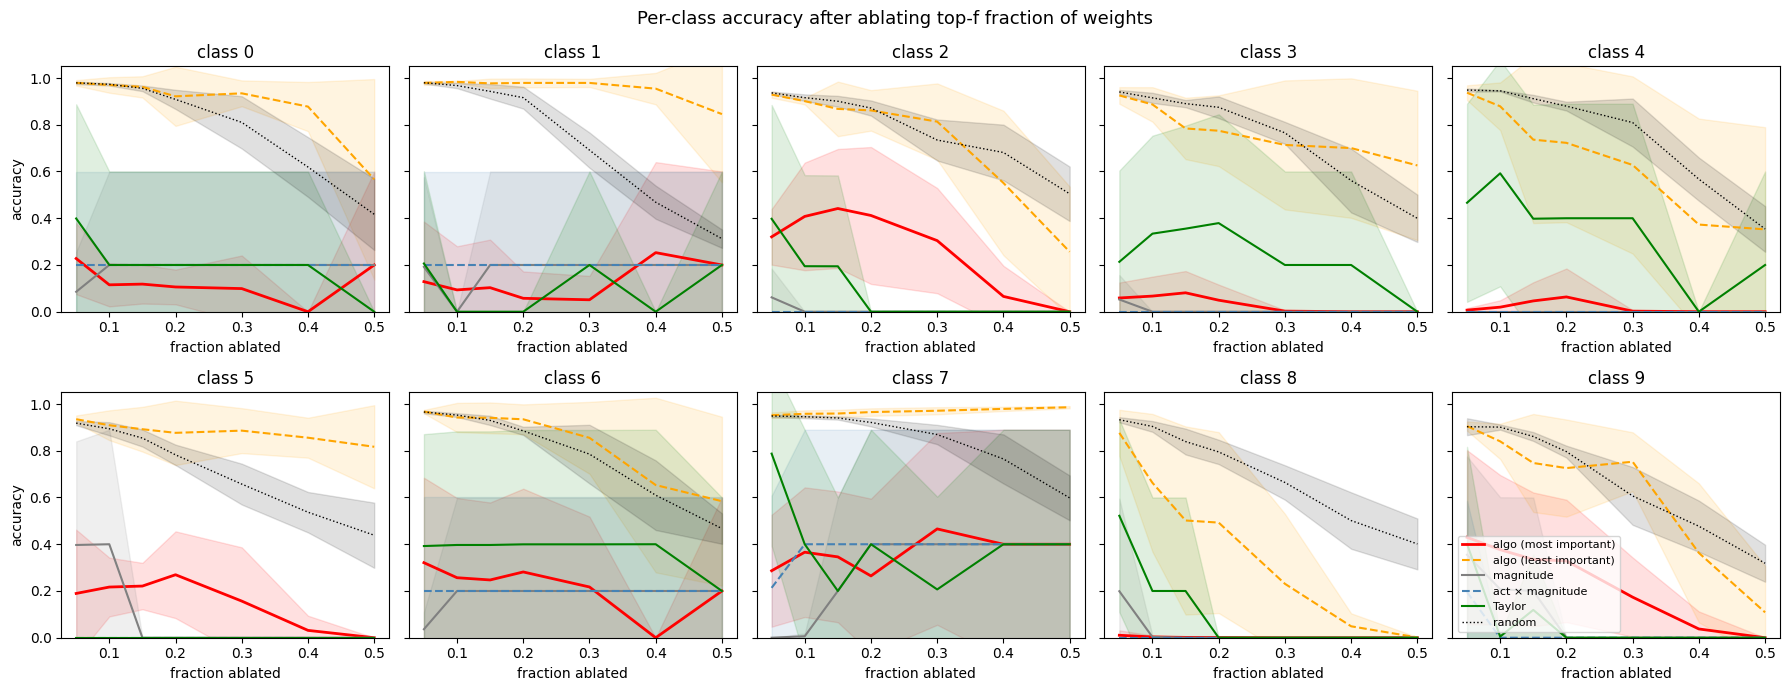

In [45]:
METHOD_STYLES = {
    'algo_top':     dict(color='red',    lw=2.0, ls='-',  label='algo (most important)'),
    'algo_bottom':  dict(color='orange', lw=1.5, ls='--', label='algo (least important)'),
    'magnitude':    dict(color='gray',   lw=1.5, ls='-',  label='magnitude'),
    'act_magnitude':dict(color='steelblue', lw=1.5, ls='--', label='act × magnitude'),
    'taylor':       dict(color='green',  lw=1.5, ls='-',  label='Taylor'),
    'random':       dict(color='black',  lw=1.0, ls=':',  label='random'),
}

valid = [r for r in all_results if r is not None]

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
axes = axes.flatten()

for d in range(N_CLASSES):
    ax = axes[d]
    for method in METHODS:
        accs = np.array([
            [r[method][d][f][d] for f in ABLATION_FRACS]
            for r in valid
        ])
        mu  = accs.mean(axis=0)
        std = accs.std(axis=0)
        st = METHOD_STYLES[method]
        ax.plot(ABLATION_FRACS, mu, color=st['color'], lw=st['lw'],
                ls=st['ls'], label=st['label'])
        ax.fill_between(ABLATION_FRACS, mu - std, mu + std,
                        color=st['color'], alpha=0.12)
    ax.set_title(f'class {d}')
    ax.set_xlabel('fraction ablated')
    if d % 5 == 0:
        ax.set_ylabel('accuracy')
    ax.set_ylim(0, 1.05)

axes[-1].legend(loc='lower left', fontsize=8)
fig.suptitle('Per-class accuracy after ablating top-f fraction of weights', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(FIG_ABL, 'per_class_accuracy.pdf'), bbox_inches='tight')
plt.show()

## AUC summary — lower AUC ⟹ steeper degradation

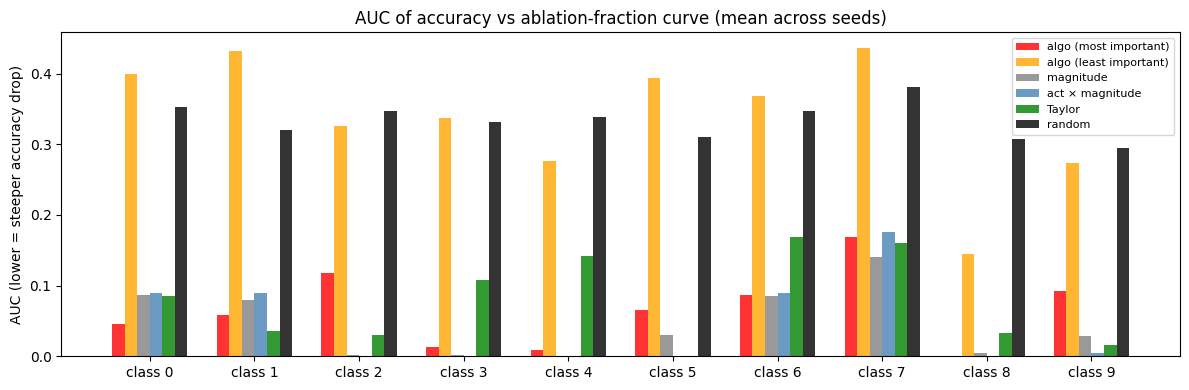

method            cls0  cls1  cls2  cls3  cls4  cls5  cls6  cls7  cls8  cls9
algo_top          0.045  0.058  0.118  0.013  0.008  0.066  0.086  0.169  0.001  0.092
algo_bottom       0.400  0.432  0.326  0.337  0.276  0.394  0.369  0.436  0.145  0.273
magnitude         0.087  0.080  0.002  0.001  0.000  0.030  0.086  0.140  0.005  0.029
act_magnitude     0.090  0.090  0.000  0.000  0.000  0.000  0.090  0.175  0.000  0.005
taylor            0.085  0.035  0.029  0.108  0.141  0.000  0.169  0.160  0.033  0.016
random            0.353  0.320  0.346  0.332  0.338  0.310  0.348  0.380  0.307  0.295


In [46]:
fracs = np.array(ABLATION_FRACS)

auc_table = {}  # method → (n_classes,) mean AUC across seeds
for method in METHODS:
    per_class_auc = []
    for d in range(N_CLASSES):
        seed_aucs = [
            trapezoid([r[method][d][f][d] for f in ABLATION_FRACS], fracs)
            for r in valid
        ]
        per_class_auc.append(np.mean(seed_aucs))
    auc_table[method] = np.array(per_class_auc)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(N_CLASSES)
width = 0.12
for k, method in enumerate(METHODS):
    st = METHOD_STYLES[method]
    ax.bar(x + k * width, auc_table[method], width,
           color=st['color'], label=st['label'], alpha=0.8)
ax.set_xticks(x + width * (len(METHODS) - 1) / 2)
ax.set_xticklabels([f'class {d}' for d in range(N_CLASSES)])
ax.set_ylabel('AUC (lower = steeper accuracy drop)')
ax.set_title('AUC of accuracy vs ablation-fraction curve (mean across seeds)')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_ABL, 'auc_summary.pdf'), bbox_inches='tight')
plt.show()

# print numeric table
header = 'method          ' + ''.join(f'  cls{d}' for d in range(N_CLASSES))
print(header)
for method in METHODS:
    row = f'{method:<16}' + ''.join(f'  {v:.3f}' for v in auc_table[method])
    print(row)

## Cross-class side-effects
When ablating weights for class d, how much do *other* classes suffer?

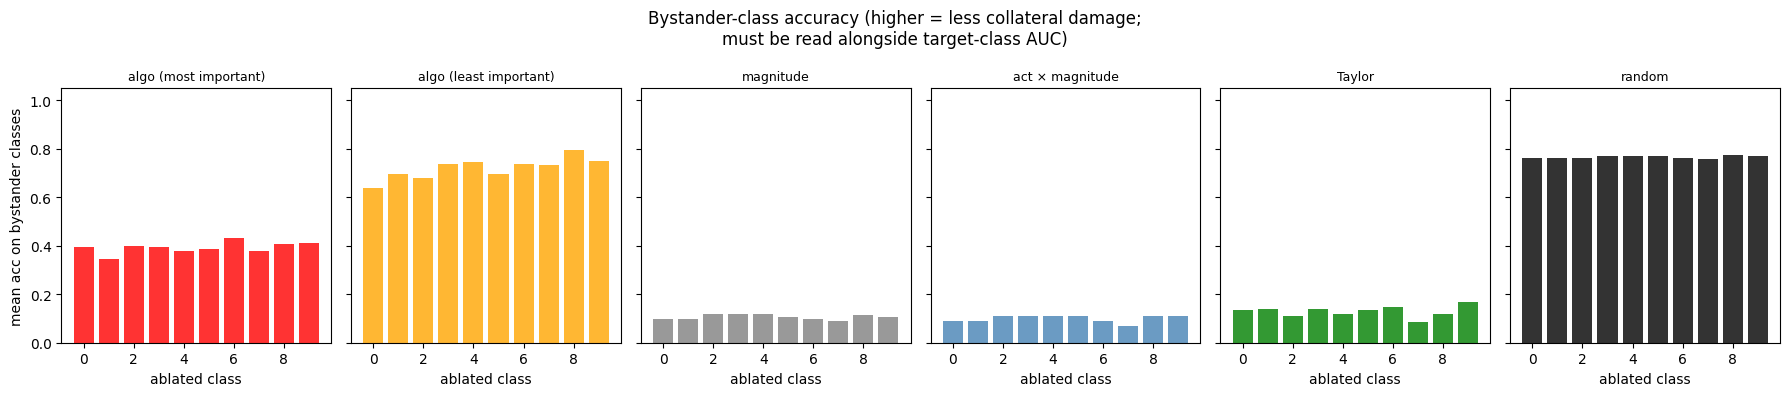

In [47]:
# For each method x class d: mean accuracy on the OTHER N_CLASSES-1 classes
# across all ablation fractions and seeds.
#
# NOTE: 'higher' means bystander classes are better preserved -- NOT that the
# method is class-specific.  Random is highest because it causes uniform mild
# damage; true class-specificity requires LOW target-class AUC alongside HIGH
# bystander accuracy.  See the 2-D summary table in the next cell.

fig, axes = plt.subplots(1, len(METHODS), figsize=(18, 4), sharey=True)

for ax, method in zip(axes, METHODS):
    mat = np.full((len(valid), N_CLASSES, len(ABLATION_FRACS)), np.nan)
    for si, r in enumerate(valid):
        for d in range(N_CLASSES):
            for fi, f in enumerate(ABLATION_FRACS):
                other_accs = [r[method][d][f][c]
                              for c in range(N_CLASSES) if c != d]
                mat[si, d, fi] = np.mean(other_accs)

    mean_side_effect = mat.mean(axis=(0, 2))   # (N_CLASSES,)

    ax.bar(range(N_CLASSES), mean_side_effect,
           color=METHOD_STYLES[method]['color'], alpha=0.8)
    ax.set_title(METHOD_STYLES[method]['label'], fontsize=9)
    ax.set_xlabel('ablated class')
    ax.set_ylim(0, 1.05)
    if ax is axes[0]:
        ax.set_ylabel('mean acc on bystander classes')

fig.suptitle('Bystander-class accuracy (higher = less collateral damage;\n'
             'must be read alongside target-class AUC)', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_ABL, 'bystander_accuracy.pdf'), bbox_inches='tight')
plt.show()


In [48]:
# 2-D specificity summary: for a truly class-specific method we want
#   LOW  target AUC  (damage the target class)
#   HIGH others AUC  (spare bystander classes -- ideally close to random)

fracs = np.array(ABLATION_FRACS)

rows = []
for method in METHODS:
    auc_t_all, auc_o_all = [], []
    for r in valid:
        for d in range(N_CLASSES):
            at = trapezoid([r[method][d][f][d] for f in ABLATION_FRACS], fracs)
            ao = np.mean([trapezoid([r[method][d][f][c] for f in ABLATION_FRACS], fracs)
                          for c in range(N_CLASSES) if c != d])
            auc_t_all.append(at)
            auc_o_all.append(ao)
    mean_t = np.mean(auc_t_all)
    mean_o = np.mean(auc_o_all)
    rows.append((method, mean_t, mean_o, mean_o - mean_t))

print('method          AUC_target  AUC_others  gap(others-target)')
print('-' * 58)
for method, mt, mo, gap in rows:
    print(f'{method:<16}  {mt:.4f}      {mo:.4f}      {gap:+.4f}')

print()
print('Ideal class-specific method: low AUC_target + AUC_others close to random.')
rand_o = next(mo for m, _, mo, _ in rows if m == 'random')
print(f'Random AUC_others = {rand_o:.4f} (reference for sparing bystanders).')


method          AUC_target  AUC_others  gap(others-target)
----------------------------------------------------------
algo_top          0.0656      0.1619      +0.0962
algo_bottom       0.3388      0.3110      -0.0278
magnitude         0.0460      0.0460      -0.0000
act_magnitude     0.0450      0.0450      +0.0000
taylor            0.0778      0.0523      -0.0255
random            0.3329      0.3317      -0.0012

Ideal class-specific method: low AUC_target + AUC_others close to random.
Random AUC_others = 0.3317 (reference for sparing bystanders).


## Statistical tests

Five targeted tests (A-E) replace the original Tests 1 and 2.

**Test A -- algo_top degrades target faster than non-specific baselines**  
H1: `AUC_target(algo_top) < AUC_target(random)` and `< AUC_target(taylor)`.  
Magnitude/act_magnitude are omitted: they are *globally* catastrophic and happen to have
even lower target AUC than algo_top, making that comparison meaningless for validating
class-specificity.

**Test B -- algo_top within-run specificity**  
H1: `AUC_others(algo_top) > AUC_target(algo_top)` -- bystander classes survive longer
than the targeted class *within the same ablation run*.

**Test C -- algo_bottom protects the target class**  
H1: `AUC_target(algo_bottom) > AUC_target(magnitude/taylor)` -- ablating least-important
weights preserves the target better than ablating globally/class-important weights.

**Test D -- algo_bottom collateral damage (new)**  
H1: `AUC_target(algo_bottom) > AUC_others(algo_bottom)` -- *within* algo_bottom's own
ablation run, the target class is preserved better than bystanders. The least-important
weights for class d are somewhat more disruptive to other classes than to class d itself.

**Test E -- direct ranking validation (new)**  
H1: `AUC_target(algo_top) < AUC_target(algo_bottom)` -- ablating most-important weights
damages the target more than ablating least-important weights.

All tests use a one-sided paired Wilcoxon signed-rank test, n = 5 seeds x 10 classes = 50
pairs. Within each seed the 10 class observations share the same underlying model, so they
are not strictly independent; a per-seed summary (n=5 means) is printed alongside each
test to confirm consistency across model instances.

*(Original Test 2 retired: its specificity metric used fraction 0.05 as the clean
reference, but by that fraction algo_top has already crashed the target to near zero --
subsequent fractions show bystanders still falling, making the score spuriously negative.
Test B is the correct replacement.)*


In [49]:
from scipy.stats import wilcoxon
import warnings

fracs = np.array(ABLATION_FRACS)
BASELINES = ['magnitude', 'act_magnitude', 'taylor', 'random']

def target_aucs(method):
    # AUC of target-class accuracy curve, shape (n_seeds, N_CLASSES)
    return np.array([
        [trapezoid([r[method][d][f][d] for f in ABLATION_FRACS], fracs)
         for d in range(N_CLASSES)]
        for r in valid
    ])

def _wilcoxon(a, b, alt='greater'):
    diff = a - b
    if np.all(diff == 0):
        return np.nan, 1.0
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return wilcoxon(diff, alternative=alt)

def _seed_summary(a, b):
    # Per-seed mean difference (a - b), averaged over classes, n=5
    diff = (a - b).mean(axis=1)
    return f'  seed deltas = {np.round(diff, 3)}'

# ====================================================================
print('=' * 68)
print('TEST A -- algo_top degrades target faster than non-specific baselines')
print('  H1: AUC_target(algo_top) < AUC_target(baseline)')
print('  Compared vs random (no class info) and taylor (class-specific rival).')
print('  Magnitude/act_magnitude omitted: globally catastrophic, lower AUC')
print('  than algo_top by accident -- not a meaningful comparison.')
print('=' * 68)

a_top = target_aucs('algo_top')
for bm in ['taylor', 'random']:
    b = target_aucs(bm)
    _, p = _wilcoxon(b.ravel(), a_top.ravel(), 'greater')
    sign = '*' if p < 0.05 else ('+' if p < 0.10 else ' ')
    print(f'  vs {bm:<10}  AUC algo_top={a_top.mean():.4f}  {bm}={b.mean():.4f}'
          f'  delta={b.mean()-a_top.mean():+.4f}  p={p:.4f} {sign}')
    print(_seed_summary(b, a_top))

# ====================================================================
print()
print('=' * 68)
print('TEST C -- algo_bottom protects target class vs weight-based baselines')
print('  H1: AUC_target(algo_bottom) > AUC_target(baseline)')
print('=' * 68)

a_bot = target_aucs('algo_bottom')
for bm in ['magnitude', 'act_magnitude', 'taylor', 'random']:
    b = target_aucs(bm)
    _, p = _wilcoxon(a_bot.ravel(), b.ravel(), 'greater')
    sign = '*' if p < 0.05 else ('+' if p < 0.10 else ' ')
    print(f'  vs {bm:<16}  AUC algo_bottom={a_bot.mean():.4f}  {bm}={b.mean():.4f}'
          f'  delta={a_bot.mean()-b.mean():+.4f}  p={p:.4f} {sign}')
    print(_seed_summary(a_bot, b))

# ====================================================================
print()
print('=' * 68)
print('TEST E -- direct ranking validation')
print('  H1: AUC_target(algo_top) < AUC_target(algo_bottom)')
print('  Most-important weights damage the target more than least-important.')
print('=' * 68)

_, p = _wilcoxon(a_bot.ravel(), a_top.ravel(), 'greater')
sign = '*' if p < 0.05 else ('+' if p < 0.10 else ' ')
print(f'  AUC algo_top={a_top.mean():.4f}  algo_bottom={a_bot.mean():.4f}'
      f'  delta={a_bot.mean()-a_top.mean():+.4f}  p={p:.4f} {sign}')
print(_seed_summary(a_bot, a_top))


TEST A -- algo_top degrades target faster than non-specific baselines
  H1: AUC_target(algo_top) < AUC_target(baseline)
  Compared vs random (no class info) and taylor (class-specific rival).
  Magnitude/act_magnitude omitted: globally catastrophic, lower AUC
  than algo_top by accident -- not a meaningful comparison.
  vs taylor      AUC algo_top=0.0656  taylor=0.0778  delta=+0.0122  p=0.7418  
  seed deltas = [-0.016 -0.022  0.023  0.062  0.015]
  vs random      AUC algo_top=0.0656  random=0.3329  delta=+0.2673  p=0.0000 *
  seed deltas = [0.23  0.264 0.254 0.309 0.279]

TEST C -- algo_bottom protects target class vs weight-based baselines
  H1: AUC_target(algo_bottom) > AUC_target(baseline)
  vs magnitude         AUC algo_bottom=0.3388  magnitude=0.0460  delta=+0.2928  p=0.0000 *
  seed deltas = [0.3   0.328 0.273 0.295 0.268]
  vs act_magnitude     AUC algo_bottom=0.3388  act_magnitude=0.0450  delta=+0.2938  p=0.0000 *
  seed deltas = [0.302 0.328 0.274 0.295 0.27 ]
  vs taylor    

### Tests B and D -- Within-run class specificity

For each (seed, target class d), compare the AUC of the *target-class* accuracy curve
against the *mean AUC of the 9 bystander classes*, all within the same ablation run.

**Test B (algo_top):** H1: `AUC_others > AUC_target` -- the target class drops *faster*
than bystanders, confirming class-specific damage.  
**Test D (algo_bottom, new):** H1: `AUC_target > AUC_others` -- the target class drops
*slower* than bystanders, confirming that the least-important-for-d weights cause more
collateral damage to other classes than to class d itself.

Both use a one-sided Wilcoxon, n = 50 pairs. The test direction is *opposite* for the two
methods -- this is by design.

Note: magnitude/act_magnitude show a near-zero gap in the wrong direction -- precision
artefact (both AUCs ~0.046, network essentially dead). The meaningful comparison is the
effect size (delta), not just p.


TEST B -- algo_top: target drops faster than bystanders
  H1: AUC_others(algo_top) > AUC_target(algo_top)
  algo_top  AUC_target=0.0656  AUC_others=0.1619  delta(others-target)=+0.0962  p=0.0000 *
  seed deltas = [0.061 0.098 0.081 0.124 0.117]

All methods (for reference):
  algo_top          AUC_target=0.0656  AUC_others=0.1619  delta=+0.0962  p=0.0000 *
  algo_bottom       AUC_target=0.3388  AUC_others=0.3110  delta=-0.0278  p=0.9753  
  magnitude         AUC_target=0.0460  AUC_others=0.0460  delta=-0.0000  p=0.0004 *
  act_magnitude     AUC_target=0.0450  AUC_others=0.0450  delta=-0.0000  p=0.0000 *
  taylor            AUC_target=0.0778  AUC_others=0.0523  delta=-0.0255  p=0.1348  
  random            AUC_target=0.3329  AUC_others=0.3317  delta=-0.0012  p=0.5305  

TEST D -- algo_bottom: target drops SLOWER than bystanders
  H1: AUC_target(algo_bottom) > AUC_others(algo_bottom)
  Direction OPPOSITE to Test B: least-important-for-d weights cause
  more collateral damage to other cla

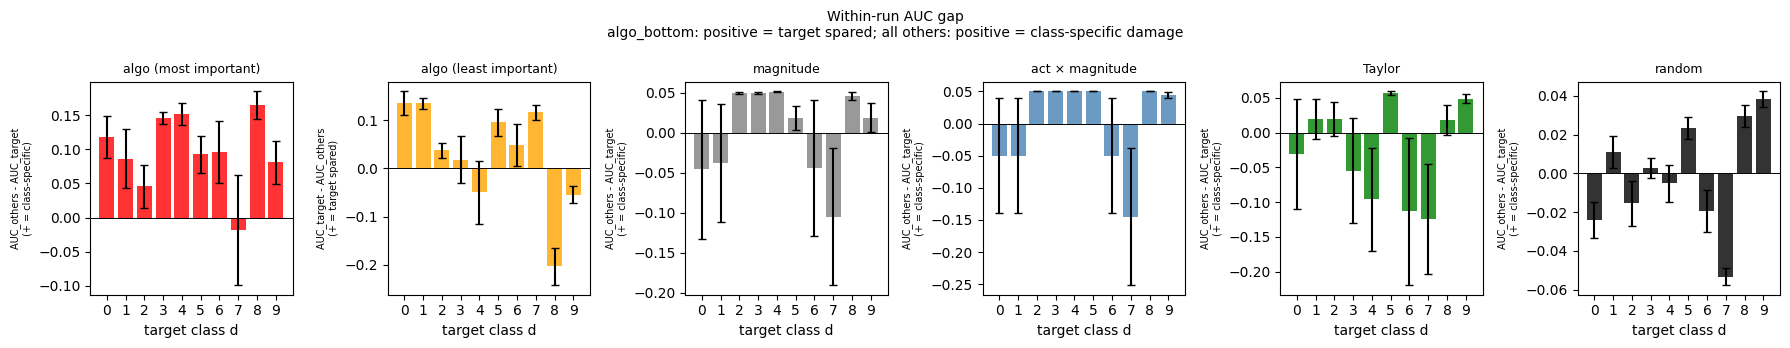

In [50]:
def within_run_aucs(method):
    # For each (seed, target class d):
    #   auc_target = AUC of acc[d] curve
    #   auc_others = mean AUC of acc[c] for c != d
    # Returns shape (n_seeds, N_CLASSES) each.
    auc_target = np.zeros((len(valid), N_CLASSES))
    auc_others = np.zeros((len(valid), N_CLASSES))
    for si, r in enumerate(valid):
        for d in range(N_CLASSES):
            auc_target[si, d] = trapezoid(
                [r[method][d][f][d] for f in ABLATION_FRACS], fracs)
            auc_others[si, d] = np.mean([
                trapezoid([r[method][d][f][c] for f in ABLATION_FRACS], fracs)
                for c in range(N_CLASSES) if c != d
            ])
    return auc_target, auc_others

# ── Test B: algo_top within-run specificity ───────────────────────────────
print('=' * 68)
print('TEST B -- algo_top: target drops faster than bystanders')
print('  H1: AUC_others(algo_top) > AUC_target(algo_top)')
print('=' * 68)

at_top, ao_top = within_run_aucs('algo_top')
_, p_B = _wilcoxon(ao_top.ravel(), at_top.ravel(), 'greater')
sign = '*' if p_B < 0.05 else ('+' if p_B < 0.10 else ' ')
print(f'  algo_top  AUC_target={at_top.mean():.4f}  AUC_others={ao_top.mean():.4f}'
      f'  delta(others-target)={(ao_top-at_top).mean():+.4f}  p={p_B:.4f} {sign}')
print(_seed_summary(ao_top, at_top))

print()
print('All methods (for reference):')
for method in METHODS:
    at, ao = within_run_aucs(method)
    _, p = _wilcoxon(ao.ravel(), at.ravel(), 'greater')
    sign = '*' if p < 0.05 else ('+' if p < 0.10 else ' ')
    print(f'  {method:<16}  AUC_target={at.mean():.4f}  AUC_others={ao.mean():.4f}'
          f'  delta={( ao-at).mean():+.4f}  p={p:.4f} {sign}')

# ── Test D: algo_bottom collateral damage ─────────────────────────────────
print()
print('=' * 68)
print('TEST D -- algo_bottom: target drops SLOWER than bystanders')
print('  H1: AUC_target(algo_bottom) > AUC_others(algo_bottom)')
print('  Direction OPPOSITE to Test B: least-important-for-d weights cause')
print('  more collateral damage to other classes than to class d itself.')
print('=' * 68)

at_bot, ao_bot = within_run_aucs('algo_bottom')
_, p_D = _wilcoxon(at_bot.ravel(), ao_bot.ravel(), 'greater')
sign = '*' if p_D < 0.05 else ('+' if p_D < 0.10 else ' ')
print(f'  algo_bottom  AUC_target={at_bot.mean():.4f}  AUC_others={ao_bot.mean():.4f}'
      f'  delta(target-others)={(at_bot-ao_bot).mean():+.4f}  p={p_D:.4f} {sign}')
print(_seed_summary(at_bot, ao_bot))

# ── Visualisation: within-run AUC gap per class ───────────────────────────
fig, axes = plt.subplots(1, len(METHODS), figsize=(18, 3.5), sharey=False)
for ax, method in zip(axes, METHODS):
    at, ao = within_run_aucs(method)
    if method == 'algo_bottom':
        # Success = target > others: plot target - others
        gap = at - ao
        yl = 'AUC_target - AUC_others\n(+ = target spared)'
    else:
        # Success = others > target: plot others - target
        gap = ao - at
        yl = 'AUC_others - AUC_target\n(+ = class-specific)'
    mu  = gap.mean(axis=0)
    sem = gap.std(axis=0) / np.sqrt(len(valid))
    ax.bar(range(N_CLASSES), mu, yerr=sem,
           color=METHOD_STYLES[method]['color'], alpha=0.8, capsize=3)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_title(METHOD_STYLES[method]['label'], fontsize=9)
    ax.set_xlabel('target class d')
    ax.set_xticks(range(N_CLASSES))
    ax.set_ylabel(yl, fontsize=7)

fig.suptitle(
    'Within-run AUC gap\n'
    'algo_bottom: positive = target spared; all others: positive = class-specific damage',
    fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(FIG_ABL, 'within_run_auc_gap.pdf'), bbox_inches='tight')
plt.show()


---
## Section 3: Causal Circuit Ablation

For each class `d` and seed `s`:
1. Run `dfs_trace` on **class-d samples only** → class-specific importance scores.
2. Ablate the class circuit: zero all weights at or above the `p`-th percentile of
   importance (varying `p` = 50–99). Higher `p` → fewer, more critical weights ablated.
3. Measure **target class accuracy** and **mean bystander accuracy** on the full test set.

If the circuit is a real functional unit, we expect the target class to drop more than
bystanders — its most critical weights were removed, while bystanders relied on different weights.

In [51]:
def circuit_keys_at_pct(scores, pct):
    vals = np.array(list(scores.values()))
    thr  = np.percentile(vals, pct)
    return [k for k, v in scores.items() if v >= thr]

def circuit_fraction(keys, model):
    total = sum(model.layers[li].weight.numel()
                for li in model.linear_layer_indices())
    return len(keys) / total

In [52]:
# ── Causal ablation sweep (5 seeds × 10 classes × 5 percentiles) ───────────────
# Cached per seed; each seed takes ~5-10 min on first run.
causal = {}   # causal[s][d] = {'baseline_accs', 'all_class_accs', 'circuit_fracs'}

for s, seed_dir in enumerate(SEED_DIRS):
    _p = os.path.join(CACHE_DIR, f'causal_seed{s}.pkl')
    if os.path.exists(_p):
        with open(_p, 'rb') as f:
            causal[s] = pickle.load(f)
        print(f'Seed {s}: loaded from cache')
        continue

    print(f'Seed {s}: computing…')
    model_s, _ = load_experiment(seed_dir, device=DEVICE); model_s.eval()
    data_s = collect_layer_inputs(model_s, test_ds, label_transform=None,
                                   n_per_class=N_PER_CLASS, device=DEVICE)
    li_s   = data_s['layer_inputs']   # (n_total, n_in) per layer
    tgt_s  = data_s['targets']         # (n_total,)
    base_accs = per_class_accuracy(model_s, test_loader, None, DEVICE)

    causal[s] = {}
    for d in range(N_CLASSES):
        mask_d   = (tgt_s == d)
        li_d     = [x[mask_d] for x in li_s]   # class-d layer inputs
        _root_d  = bft(model_s, li_d, k_max=K_TRACE_S3, n_branches=1, stimulus_threshold=STIM_THRESH)
        trace_d  = [_root_d]
        _nd = _root_d
        while _nd['children']:
            _nd = _nd['children'][0]
            trace_d.append(_nd)
        scores_d = extract_importance_scores(trace_d)

        all_accs = {}
        fracs    = {}
        for pct in PERCENTILES:
            keys       = circuit_keys_at_pct(scores_d, pct)
            abl_model  = ablate_model(model_s, keys)
            all_accs[pct] = per_class_accuracy(abl_model, test_loader, None, DEVICE)
            fracs[pct]    = circuit_fraction(keys, model_s)

        causal[s][d] = {'baseline_accs': base_accs,
                         'all_class_accs': all_accs,
                         'circuit_fracs': fracs}
        print(f'  class {d}: target drop@90 = '
              f'{base_accs[d] - all_accs[90][d]:.3f}  '
              f'circuit_frac@90 = {fracs[90]:.3f}')

    with open(_p, 'wb') as f:
        pickle.dump(causal[s], f)
    print(f'  Saved seed {s}.')


Seed 0: loaded from cache
Seed 1: loaded from cache
Seed 2: loaded from cache
Seed 3: loaded from cache
Seed 4: loaded from cache


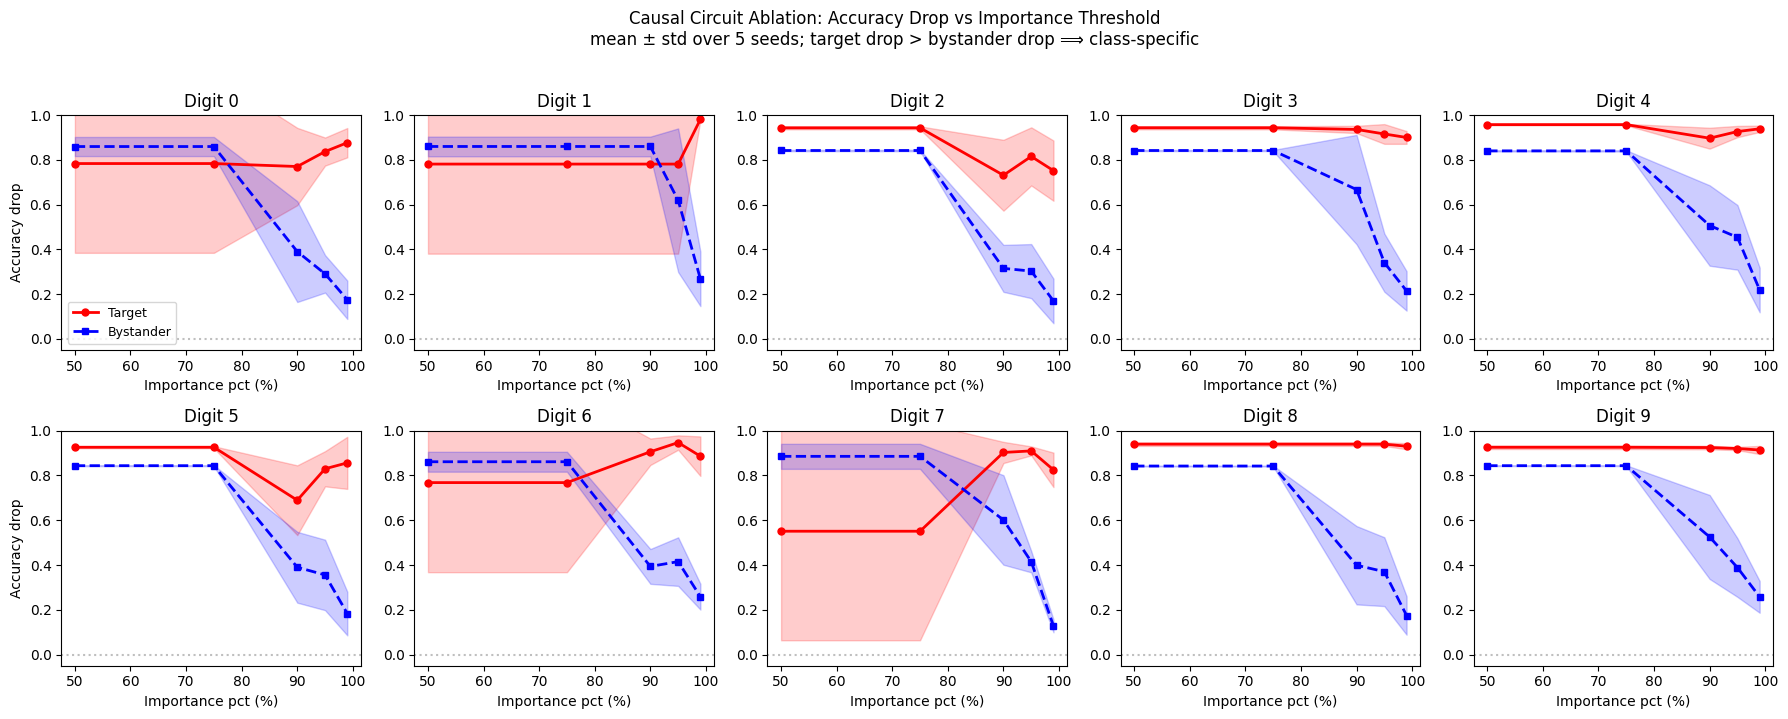

In [53]:
# ── Plot: per-class accuracy curves ────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for d in range(N_CLASSES):
    ax = axes[d]
    tgt_mean, bys_mean = [], []
    tgt_std,  bys_std  = [], []
    for pct in PERCENTILES:
        t_vals, b_vals = [], []
        for s in range(len(SEED_DIRS)):
            base = causal[s][d]['baseline_accs']
            abl  = causal[s][d]['all_class_accs'][pct]
            t_vals.append(base[d] - abl[d])
            b_vals.append(np.mean([base[c] - abl[c] for c in range(N_CLASSES) if c != d]))
        tgt_mean.append(np.mean(t_vals)); tgt_std.append(np.std(t_vals))
        bys_mean.append(np.mean(b_vals)); bys_std.append(np.std(b_vals))

    ax.plot(PERCENTILES, tgt_mean, 'r-o', lw=2, ms=5, label='Target')
    ax.fill_between(PERCENTILES,
                    np.array(tgt_mean) - np.array(tgt_std),
                    np.array(tgt_mean) + np.array(tgt_std), alpha=0.2, color='r')
    ax.plot(PERCENTILES, bys_mean, 'b--s', lw=2, ms=5, label='Bystander')
    ax.fill_between(PERCENTILES,
                    np.array(bys_mean) - np.array(bys_std),
                    np.array(bys_mean) + np.array(bys_std), alpha=0.2, color='b')
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    ax.set_title(f'Digit {d}', fontsize=12)
    ax.set_xlabel('Importance pct (%)')
    if d % 5 == 0: ax.set_ylabel('Accuracy drop')
    ax.set_ylim(-0.05, 1.0)
    if d == 0: ax.legend(fontsize=9)

plt.suptitle('Causal Circuit Ablation: Accuracy Drop vs Importance Threshold\n'
             'mean \u00b1 std over 5 seeds; target drop > bystander drop \u27f9 class-specific', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_ABL, 'fig2a_causal_curves.pdf'), bbox_inches='tight')
plt.show()

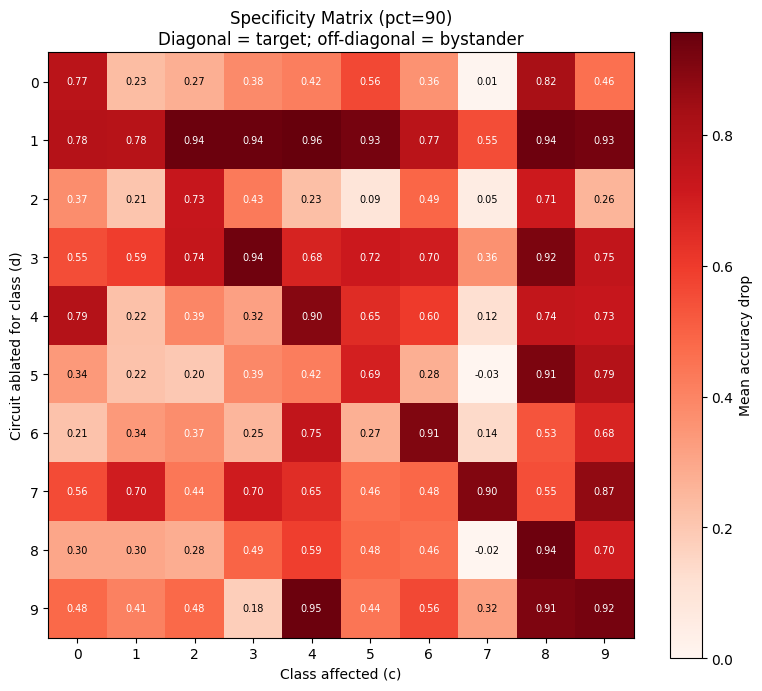

Target (diag):    0.848 ± 0.090
Bystander (off):  0.505 ± 0.256


In [54]:
# ── Plot: specificity matrix at pct=90 ─────────────────────────────────────────
PCT_SPEC = 90
spec_mat = np.zeros((N_CLASSES, N_CLASSES))
for d in range(N_CLASSES):
    for c in range(N_CLASSES):
        drops = [causal[s][d]['baseline_accs'][c] - causal[s][d]['all_class_accs'][PCT_SPEC][c]
                 for s in range(len(SEED_DIRS))]
        spec_mat[d, c] = np.mean(drops)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(spec_mat, vmin=0, cmap='Reds')
plt.colorbar(im, ax=ax, label='Mean accuracy drop')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{spec_mat[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if spec_mat[i,j] > 0.35 else 'black')
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xlabel('Class affected (c)'); ax.set_ylabel('Circuit ablated for class (d)')
ax.set_title(f'Specificity Matrix (pct={PCT_SPEC})\nDiagonal = target; off-diagonal = bystander')
plt.tight_layout()
plt.savefig(os.path.join(FIG_ABL, 'fig2b_specificity.pdf'), bbox_inches='tight')
plt.show()

diag     = np.diag(spec_mat)
offdiag  = spec_mat[~np.eye(N_CLASSES, dtype=bool)]
print(f'Target (diag):    {diag.mean():.3f} ± {diag.std():.3f}')
print(f'Bystander (off):  {offdiag.mean():.3f} ± {offdiag.std():.3f}')

In [55]:
# ── Wilcoxon: target drop > bystander drop at pct=90 ───────────────────────────
tgt_90, bys_90 = [], []
for s in range(len(SEED_DIRS)):
    for d in range(N_CLASSES):
        base = causal[s][d]['baseline_accs']
        abl  = causal[s][d]['all_class_accs'][90]
        tgt_90.append(base[d] - abl[d])
        bys_90.append(np.mean([base[c] - abl[c] for c in range(N_CLASSES) if c != d]))

tgt_90 = np.array(tgt_90); bys_90 = np.array(bys_90)
diffs  = tgt_90 - bys_90
stat, pval_causal = wilcoxon(diffs, alternative='greater')
diffs_90 = float(diffs.mean())

print(f'Wilcoxon H1: target_drop > bystander_drop  (n={len(diffs)} pairs)')
print(f'  Target drop:    {tgt_90.mean():.3f} ± {tgt_90.std():.3f}')
print(f'  Bystander drop: {bys_90.mean():.3f} ± {bys_90.std():.3f}')
print(f'  Difference:     {diffs.mean():.3f} ± {diffs.std():.3f}')
print(f'  stat={stat:.1f}, p={pval_causal:.4f}')

Wilcoxon H1: target_drop > bystander_drop  (n=50 pairs)
  Target drop:    0.848 ± 0.181
  Bystander drop: 0.505 ± 0.233
  Difference:     0.343 ± 0.267
  stat=1225.0, p=0.0000


In [56]:
# ── Specificity at pct=99 (top 1% of weights) ───────────────────────
tgt_99, bys_99 = [], []
for s in range(len(SEED_DIRS)):
    for d in range(N_CLASSES):
        base = causal[s][d]['baseline_accs']
        abl  = causal[s][d]['all_class_accs'][99]
        tgt_99.append(base[d] - abl[d])
        bys_99.append(np.mean([base[c] - abl[c] for c in range(N_CLASSES) if c != d]))

tgt_99 = np.array(tgt_99); bys_99 = np.array(bys_99)
diffs_99 = tgt_99 - bys_99
stat99, pval_99 = wilcoxon(diffs_99, alternative='greater')

frac_99 = np.mean([causal[s][d]['circuit_fracs'][99]
                   for s in range(len(SEED_DIRS)) for d in range(N_CLASSES)])

print(f'pct=99 (top {frac_99*100:.1f}% of weights):')
print(f'  Target drop:    {tgt_99.mean():.3f} ± {tgt_99.std():.3f}')
print(f'  Bystander drop: {bys_99.mean():.3f} ± {bys_99.std():.3f}')
print(f'  Specificity Δ:  {diffs_99.mean():.3f} ± {diffs_99.std():.3f}')
print(f'  Wilcoxon p = {pval_99:.4f}')
print(f'\npct=90 vs pct=99 specificity Δ: {diffs_90:.3f} vs {diffs_99.mean():.3f}')


pct=99 (top 1.0% of weights):
  Target drop:    0.886 ± 0.094
  Bystander drop: 0.205 ± 0.098
  Specificity Δ:  0.681 ± 0.109
  Wilcoxon p = 0.0000

pct=90 vs pct=99 specificity Δ: 0.343 vs 0.681


---
## Section 4: Gradient Attribution Comparison

Compare the NMF backward-trace pixel patterns (L1 `neural_factors[:, 0]`, class-specific
from `tree_trace`) against vanilla saliency (`|\u2202y/\u2202x|`) and integrated gradients.  
Metrics: Spearman pixel-space correlation and mean pairwise cosine distance between
class maps (class discriminability).

In [57]:
def saliency_map(model, imgs_t, target_class):
    """Mean |∂output[target]/∂input| over a batch. Returns (28,28) ndarray."""
    maps = []
    model.eval()
    for i in range(len(imgs_t)):
        x = imgs_t[i:i+1].clone().detach().requires_grad_(True)
        out, _ = model(x)
        out[0, target_class].backward()
        maps.append(x.grad[0].abs().max(dim=0).values.numpy())  # max over C=1
    return np.mean(maps, axis=0)

def integrated_gradients(model, imgs_t, target_class, n_steps=20):
    """Mean |IG| over a batch. Returns (28,28) ndarray."""
    baseline = torch.zeros(1, *imgs_t.shape[1:])
    maps = []
    model.eval()
    for i in range(len(imgs_t)):
        x = imgs_t[i:i+1]
        delta = (x - baseline).squeeze().numpy()        # (28,28)
        grads = []
        for step in range(n_steps):
            alpha = step / max(n_steps - 1, 1)
            xi = (baseline + alpha * (x - baseline)).clone().detach().requires_grad_(True)
            model(xi)[0][0, target_class].backward()
            grads.append(xi.grad.squeeze().numpy())
        ig = np.abs(np.mean(grads, axis=0) * delta)
        maps.append(ig)
    return np.mean(maps, axis=0)

In [58]:
# ── NMF class-specific pixel patterns via bft (seed 0) ──────────────────────────
# Cached: stores only neural_factors per class (not the large joint_arbors)
_p = os.path.join(CACHE_DIR, 'tree_trace_data_seed0.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        tree_data0 = pickle.load(f)
    print('Loaded bft data from cache')
else:
    print('Running bft for seed 0 — ~5 min (L1 NMF × 10 branches)…')
    root0 = bft(model0, layer_inputs0, k_max=K_TRACE,
              n_branches=N_BRANCHES, stimulus_threshold=STIM_THRESH)
    c2ch  = assign_factors_to_classes(root0, all_targets0, N_CLASSES)
    tree_data0 = {}
    for d in range(N_CLASSES):
        path = path_from_child(root0, c2ch[d])
        tree_data0[d] = {
            'neural_factors': [nd['neural_factors'] for nd in path],
            'img_factors':    [nd['img_factors']    for nd in path],
            'lambdas':        [nd['lambdas']        for nd in path],
            'layer_idx':      [nd['layer_idx']      for nd in path],
        }
    del root0
    with open(_p, 'wb') as f:
        pickle.dump(tree_data0, f)
    print('Saved.')

# Extract L1 pixel pattern per class: neural_factors at l_idx=0 → mean over neurons
nmf_pix = {}
for d in range(N_CLASSES):
    pos = tree_data0[d]['layer_idx'].index(0)   # position of L1 node in path
    nf  = tree_data0[d]['neural_factors'][pos]   # (40*784, K)
    nmf_pix[d] = nf[:, 0].reshape(40, 784).mean(axis=0).reshape(28, 28)

print('NMF pixel patterns extracted for all 10 classes.')


Loaded tree_trace data from cache
NMF pixel patterns extracted for all 10 classes.


In [59]:
# ── Compute saliency and IG maps per class ──────────────────────────────────────
N_SAL = 200   # images per class for saliency
N_IG  = 50    # images per class for IG (slower)
_p = os.path.join(CACHE_DIR, 'gradient_attributions.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        grad_data = pickle.load(f)
    print('Loaded gradient attributions from cache')
else:
    print('Computing gradient attributions (~5 min)…')
    imgs_by_class = {d: [] for d in range(N_CLASSES)}
    for imgs, labels in test_loader:
        for img, lbl in zip(imgs, labels):
            d = int(lbl)
            if len(imgs_by_class[d]) < N_SAL:
                imgs_by_class[d].append(img)

    grad_data = {'sal': {}, 'ig': {}}
    for d in range(N_CLASSES):
        imgs_t = torch.stack(imgs_by_class[d])
        print(f'  class {d}…')
        grad_data['sal'][d] = saliency_map(model0, imgs_t, d)
        grad_data['ig'][d]  = integrated_gradients(model0, imgs_t[:N_IG], d, n_steps=20)

    with open(_p, 'wb') as f:
        pickle.dump(grad_data, f)
    print('Saved.')

Loaded gradient attributions from cache


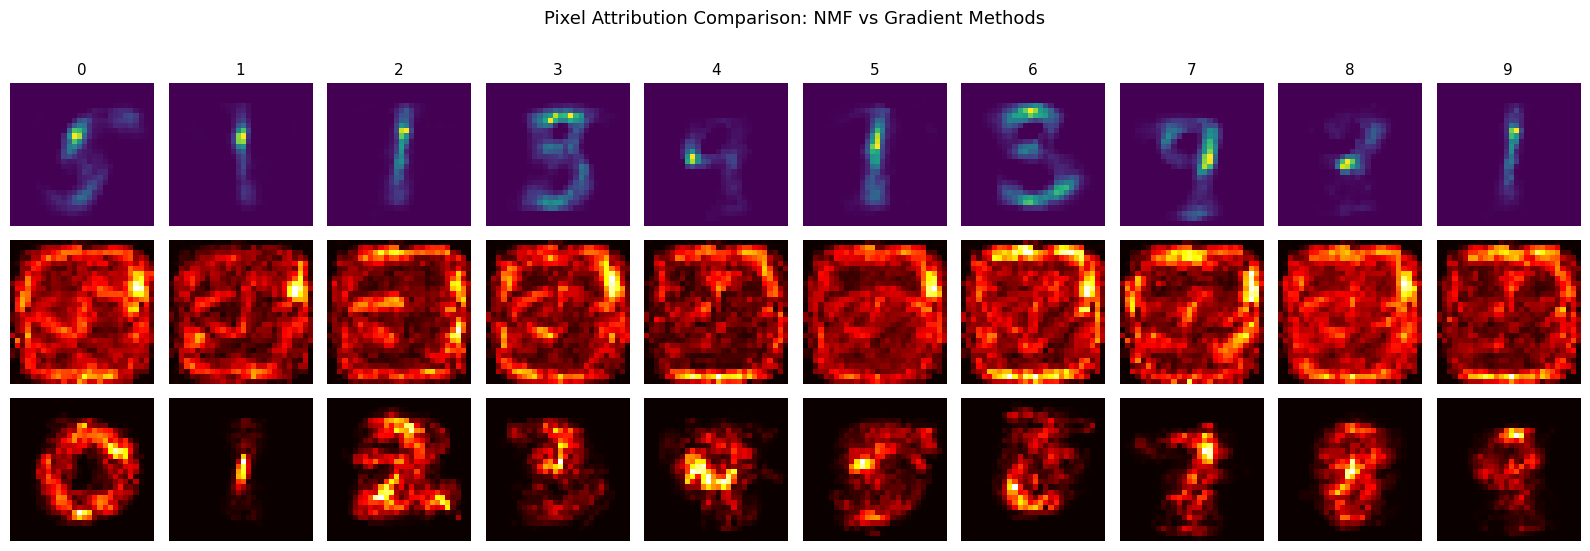

In [60]:
# ── Figure 3a: 3 × 10 attribution grid ─────────────────────────────────────────
def norm01(x):
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo + 1e-12)

fig, axes = plt.subplots(3, N_CLASSES, figsize=(N_CLASSES * 1.6, 5.5))
row_info = [
    (nmf_pix,           'viridis', 'NMF\n(backward trace)'),
    (grad_data['sal'],  'hot',     'Saliency\n|∂y/∂x|'),
    (grad_data['ig'],   'hot',     'Integrated\nGradients'),
]
for row, (pat_dict, cmap, ylabel) in enumerate(row_info):
    for d in range(N_CLASSES):
        ax = axes[row, d]
        ax.imshow(norm01(pat_dict[d]), cmap=cmap, vmin=0, vmax=1)
        if row == 0: ax.set_title(str(d), fontsize=11)
        ax.axis('off')
    axes[row, 0].set_ylabel(ylabel, fontsize=9, rotation=90)

plt.suptitle('Pixel Attribution Comparison: NMF vs Gradient Methods', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_ABL, 'fig3a_attribution_grid.pdf'), bbox_inches='tight')
plt.show()

In [61]:
# ── Spearman correlations and class discriminability ────────────────────────────
rho_ns, rho_ni, rho_si = [], [], []
for d in range(N_CLASSES):
    pn = nmf_pix[d].flatten()
    ps = grad_data['sal'][d].flatten()
    pi = grad_data['ig'][d].flatten()
    rho_ns.append(spearmanr(pn, ps).statistic)
    rho_ni.append(spearmanr(pn, pi).statistic)
    rho_si.append(spearmanr(ps, pi).statistic)

print('Spearman ρ between attribution methods (pixel-space):')
print(f'  NMF vs Saliency: {np.mean(rho_ns):.3f} ± {np.std(rho_ns):.3f}')
print(f'  NMF vs IG:       {np.mean(rho_ni):.3f} ± {np.std(rho_ni):.3f}')
print(f'  Saliency vs IG:  {np.mean(rho_si):.3f} ± {np.std(rho_si):.3f}')

def class_discriminability(pat_dict, n=10):
    """Mean pairwise cosine distance between class-specific patterns."""
    vecs = np.array([pat_dict[d].flatten() for d in range(n)])
    vecs = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)
    sim  = vecs @ vecs.T
    return 1.0 - sim[~np.eye(n, dtype=bool)].mean()

disc_nmf = class_discriminability(nmf_pix)
disc_sal = class_discriminability(grad_data['sal'])
disc_ig  = class_discriminability(grad_data['ig'])

print(f'\nClass discriminability (mean pairwise cosine distance):')
print(f'  NMF:      {disc_nmf:.4f}')
print(f'  Saliency: {disc_sal:.4f}')
print(f'  IG:       {disc_ig:.4f}')

Spearman ρ between attribution methods (pixel-space):
  NMF vs Saliency: 0.064 ± 0.132
  NMF vs IG:       0.508 ± 0.130
  Saliency vs IG:  0.038 ± 0.044

Class discriminability (mean pairwise cosine distance):
  NMF:      0.6578
  Saliency: 0.1025
  IG:       0.4222


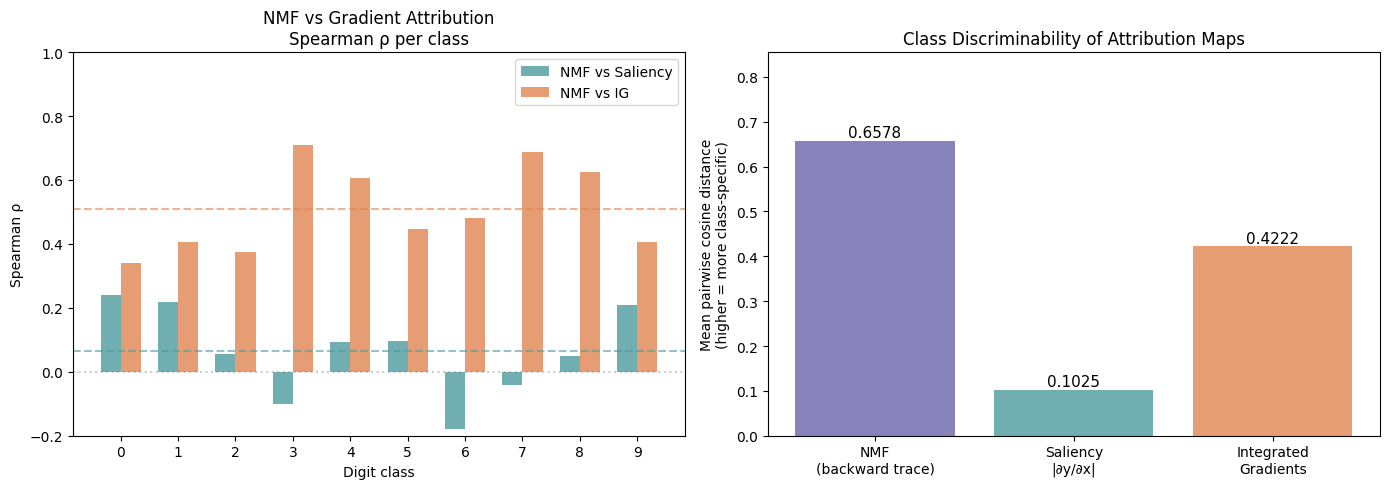

In [62]:
# ── Figure 3bc: Spearman bars + discriminability bars ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spearman per class
ax = axes[0]
x = np.arange(N_CLASSES); w = 0.35
ax.bar(x - w/2, rho_ns, w, label='NMF vs Saliency', color='#4e9a9e', alpha=0.8)
ax.bar(x + w/2, rho_ni, w, label='NMF vs IG',       color='#e08550', alpha=0.8)
ax.axhline(np.mean(rho_ns), color='#4e9a9e', ls='--', alpha=0.6)
ax.axhline(np.mean(rho_ni), color='#e08550', ls='--', alpha=0.6)
ax.axhline(0, color='gray', ls=':', alpha=0.4)
ax.set_xlabel('Digit class'); ax.set_ylabel('Spearman ρ')
ax.set_xticks(x); ax.set_xticklabels(range(N_CLASSES))
ax.set_title('NMF vs Gradient Attribution\nSpearman ρ per class')
ax.legend(); ax.set_ylim(-0.2, 1.0)

# Discriminability
ax = axes[1]
methods = ['NMF\n(backward trace)', 'Saliency\n|∂y/∂x|', 'Integrated\nGradients']
vals    = [disc_nmf, disc_sal, disc_ig]
colors  = ['#6b66aa', '#4e9a9e', '#e08550']
bars = ax.bar(methods, vals, color=colors, alpha=0.8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}',
            ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Mean pairwise cosine distance\n(higher = more class-specific)')
ax.set_title('Class Discriminability of Attribution Maps')
ax.set_ylim(0, max(vals) * 1.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_ABL, 'fig3bc_attribution_metrics.pdf'), bbox_inches='tight')
plt.show()

---
## Section 5: Cross-Class Circuit Specificity

Quantify how class-specific the backward-trace circuits are at each layer.  
Using the class-specific `tree_trace` paths from Section 3, we compute pairwise cosine similarity between L1 neural factors across all 10 digit pairs (90 pairs).  
Low off-diagonal similarity → the method discovers distinct, class-specific weight patterns rather than generic features.  
The hierarchical clustering reveals which digit classes share the most circuit structure.

In [63]:
# ── Circuit cosine similarity matrices ─────────────────────────────────────────
def circuit_sim_matrix(tree_data, l_idx_target, n_classes=10):
    """(n_classes, n_classes) cosine similarity between top neural factors at l_idx_target."""
    vecs = []
    for d in range(n_classes):
        pos = tree_data[d]['layer_idx'].index(l_idx_target)
        nf  = tree_data[d]['neural_factors'][pos]   # (n_out*n_in, K)
        vecs.append(nf[:, 0])
    vecs = np.array(vecs)
    vecs = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)
    return vecs @ vecs.T

sim_l1 = circuit_sim_matrix(tree_data0, l_idx_target=0)   # pixel-level
sim_l2 = circuit_sim_matrix(tree_data0, l_idx_target=1)   # L2 feature-level

# Spearman correlation between class-specific stimulus loadings (at L2 child)
stim_corr = np.zeros((N_CLASSES, N_CLASSES))
for d1 in range(N_CLASSES):
    for d2 in range(N_CLASSES):
        pos1 = tree_data0[d1]['layer_idx'].index(1)
        pos2 = tree_data0[d2]['layer_idx'].index(1)
        sf1 = tree_data0[d1]['img_factors'][pos1][:, 0]
        sf2 = tree_data0[d2]['img_factors'][pos2][:, 0]
        stim_corr[d1, d2] = spearmanr(sf1, sf2).statistic

mask_off = ~np.eye(N_CLASSES, dtype=bool)
print(f'L1 circuit cosine sim (off-diag): {sim_l1[mask_off].mean():.4f} ± {sim_l1[mask_off].std():.4f}')
print(f'Stim loading Spearman (off-diag): {stim_corr[mask_off].mean():.4f} ± {stim_corr[mask_off].std():.4f}')

L1 circuit cosine sim (off-diag): 0.1461 ± 0.1661
Stim loading Spearman (off-diag): -0.0289 ± 0.3436


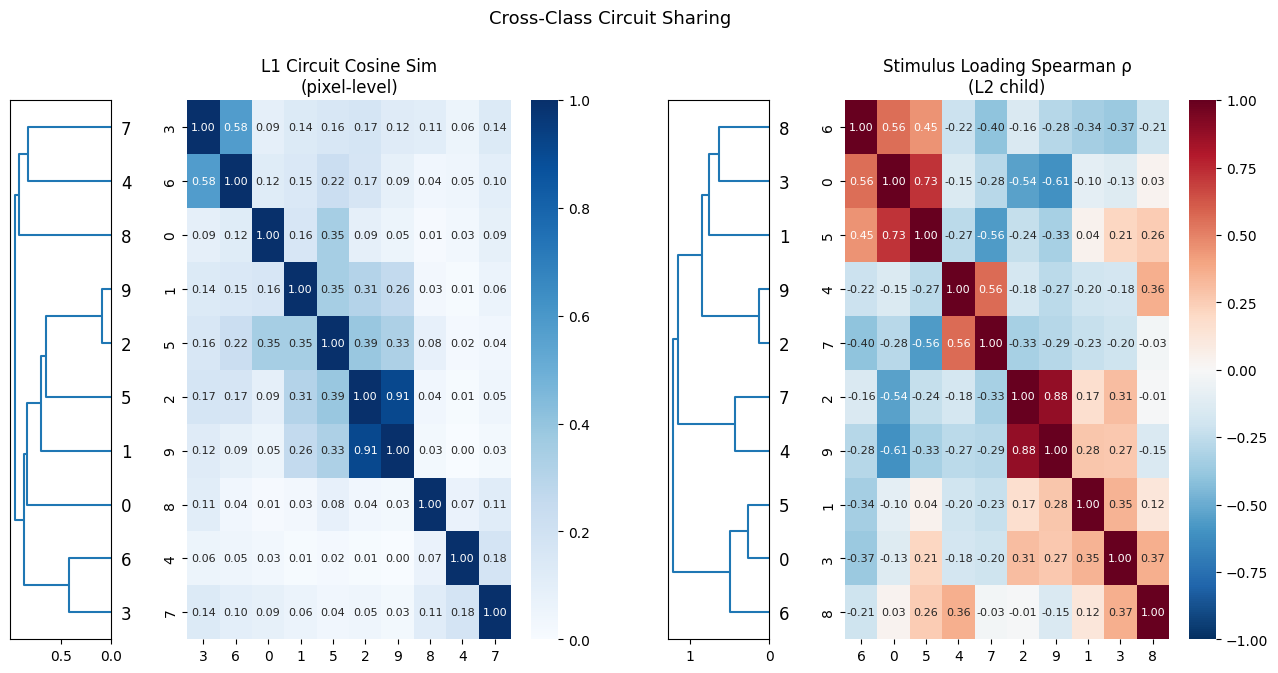

In [64]:
# ── Figure 4a: heatmaps with dendrograms ───────────────────────────────────────
def clustered_heatmap(sim, title, ax_d, ax_h):
    dist = np.clip(1 - sim, 0, None)
    dist = (dist + dist.T) / 2          # force symmetry (floating-point)
    np.fill_diagonal(dist, 0.0)
    dist_cond = squareform(dist)
    Z = linkage(dist_cond, method='average')
    dend = dendrogram(Z, ax=ax_d, orientation='left',
                      labels=[str(d) for d in range(N_CLASSES)],
                      color_threshold=0)
    order = dend['leaves']
    sim_r = sim[np.ix_(order, order)]
    vmin, vmax = (0, 1) if sim.min() >= 0 else (-1, 1)
    cmap = 'Blues' if vmin == 0 else 'RdBu_r'
    sns.heatmap(sim_r, ax=ax_h, vmin=vmin, vmax=vmax, cmap=cmap,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                xticklabels=[str(o) for o in order],
                yticklabels=[str(o) for o in order])
    ax_h.set_title(title)

fig = plt.figure(figsize=(16, 7))
gs  = fig.add_gridspec(1, 4, width_ratios=[1, 4, 1, 4], wspace=0.3)
ax_d1, ax_h1 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
ax_d2, ax_h2 = fig.add_subplot(gs[2]), fig.add_subplot(gs[3])

clustered_heatmap(sim_l1,    'L1 Circuit Cosine Sim\n(pixel-level)',    ax_d1, ax_h1)
clustered_heatmap(stim_corr, 'Stimulus Loading Spearman \u03c1\n(L2 child)', ax_d2, ax_h2)

plt.suptitle('Cross-Class Circuit Sharing', y=1.01, fontsize=13)
plt.savefig(os.path.join(FIG_ABL, 'fig4a_circuit_sharing.pdf'), bbox_inches='tight')
plt.show()


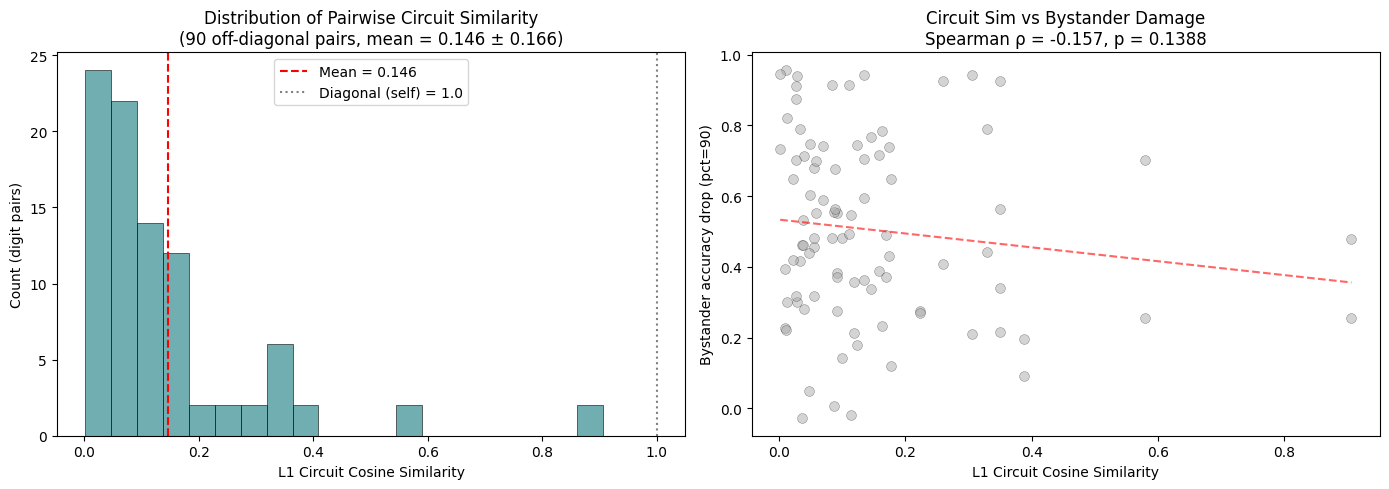

Permutation test (1000 shuffles): p = 0.9320

Key finding: L1 circuit off-diagonal mean = 0.146 (circuits are class-specific; max possible = 1.0)


In [65]:
# ── Figure 4b: distribution of off-diagonal circuit similarities ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of pairwise cosine similarities
ax = axes[0]
off_vals = sim_l1[mask_off]
ax.hist(off_vals, bins=20, color='#4e9a9e', alpha=0.8, edgecolor='k', linewidth=0.5)
ax.axvline(off_vals.mean(), color='red', ls='--', label=f'Mean = {off_vals.mean():.3f}')
ax.axvline(np.diag(sim_l1).mean(), color='gray', ls=':', label='Diagonal (self) = 1.0')
ax.set_xlabel('L1 Circuit Cosine Similarity'); ax.set_ylabel('Count (digit pairs)')
ax.set_title('Distribution of Pairwise Circuit Similarity\n'
             f'(90 off-diagonal pairs, mean = {off_vals.mean():.3f} ± {off_vals.std():.3f})')
ax.legend()

# Right: scatter retained as supplementary evidence (null result, labeled as such)
ax = axes[1]
circuit_sims_flat = sim_l1[mask_off]
bystander_flat    = spec_mat[mask_off]
rho_share, pval_share = spearmanr(circuit_sims_flat, bystander_flat)

ax.scatter(circuit_sims_flat, bystander_flat, alpha=0.5, s=50,
           c='#aaa', edgecolors='k', linewidths=0.3)
m, b = np.polyfit(circuit_sims_flat, bystander_flat, 1)
xr = np.linspace(circuit_sims_flat.min(), circuit_sims_flat.max(), 100)
ax.plot(xr, m * xr + b, 'r--', alpha=0.6)
ax.set_xlabel('L1 Circuit Cosine Similarity'); ax.set_ylabel('Bystander accuracy drop (pct=90)')
ax.set_title(f'Circuit Sim vs Bystander Damage\n'
             f'Spearman \u03c1 = {rho_share:.3f}, p = {pval_share:.4f}')

plt.tight_layout()
plt.savefig(os.path.join(FIG_ABL, 'fig4b_circuit_specificity.pdf'), bbox_inches='tight')
plt.show()

# Permutation test (retained for completeness)
rng = np.random.default_rng(42)
null_rhos = [spearmanr(rng.permutation(circuit_sims_flat), bystander_flat).statistic
             for _ in range(1000)]
pval_perm = np.mean(np.array(null_rhos) >= rho_share)
print(f'Permutation test (1000 shuffles): p = {pval_perm:.4f}')
print(f'\nKey finding: L1 circuit off-diagonal mean = {off_vals.mean():.3f} '
      f'(circuits are class-specific; max possible = 1.0)')


---
## Section 6: Summary

In [66]:
print('=' * 65)
print('SUMMARY OF KEY RESULTS')
print('=' * 65)

print('\n1. NMF Factor Stability (stimulus factors, off-diagonal cosine sim):')
for l_idx in sorted(stab):
    v = stab[l_idx]['sim_img'][mask_offdiag_stab]
    print(f'   {layer_names[l_idx]}: {v.mean():.3f} \u00b1 {v.std():.3f}  (n={len(v)})')
_stab_note = ('NOTE: if stability = 1.000, cache was built with deterministic init (nndsvda). '
              'Delete 05_cache/stability.pkl and rerun with init="random".')
if all(stab[l]['sim_img'][mask_offdiag_stab].mean() > 0.999 for l in stab):
    print(f'   *** {_stab_note} ***')

print(f'\n2. Causal Circuit Ablation (pct=90, 5 seeds \u00d7 10 classes):')
print(f'   Target drop:    {tgt_90.mean():.3f} \u00b1 {tgt_90.std():.3f}')
print(f'   Bystander drop: {bys_90.mean():.3f} \u00b1 {bys_90.std():.3f}')
print(f'   Wilcoxon p = {pval_causal:.4f}')

print(f'\n3. Gradient Attribution Comparison (seed 0):')
print(f'   NMF vs Saliency: \u03c1 = {np.mean(rho_ns):.3f} \u00b1 {np.std(rho_ns):.3f}')
print(f'   NMF vs IG:       \u03c1 = {np.mean(rho_ni):.3f} \u00b1 {np.std(rho_ni):.3f}')
print(f'   Discriminability: NMF={disc_nmf:.4f}  Sal={disc_sal:.4f}  IG={disc_ig:.4f}')

print(f'\n4. Cross-Class Circuit Specificity:')
print(f'   L1 circuit off-diagonal cosine sim: {sim_l1[mask_off].mean():.4f} \u00b1 {sim_l1[mask_off].std():.4f}')
print(f'   (Circuits are class-specific: off-diagonal mean << 1.0)')
print(f'   Circuit sim \u2192 bystander damage: Spearman \u03c1 = {rho_share:.3f}, perm p = {pval_perm:.4f}')

print('\nLaTeX table rows:')
for l_idx in sorted(stab):
    v = stab[l_idx]['sim_img'][mask_offdiag_stab]
    print(f'  NMF stability {layer_names[l_idx]} & ${v.mean():.3f} \\pm {v.std():.3f}$ \\\\')
print(f'  Causal target drop (pct=90) & ${tgt_90.mean():.3f} \\pm {tgt_90.std():.3f}$ \\\\')
print(f'  NMF vs saliency Spearman & ${np.mean(rho_ns):.3f} \\pm {np.std(rho_ns):.3f}$ \\\\')
print(f'  L1 circuit off-diag sim & ${sim_l1[mask_off].mean():.3f} \\pm {sim_l1[mask_off].std():.3f}$ \\\\')
print(f'  Circuit sim $\\to$ bystander & $\\rho={rho_share:.3f}$, $p={pval_perm:.4f}$ \\\\')


SUMMARY OF KEY RESULTS

1. NMF Factor Stability (stimulus factors, off-diagonal cosine sim):
   L1 (784→40): 0.938 ± 0.083  (n=90)
   L2 (40→20): 1.000 ± 0.000  (n=90)
   Out (20→10): 0.829 ± 0.065  (n=90)

2. Causal Circuit Ablation (pct=90, 5 seeds × 10 classes):
   Target drop:    0.848 ± 0.181
   Bystander drop: 0.505 ± 0.233
   Wilcoxon p = 0.0000

3. Gradient Attribution Comparison (seed 0):
   NMF vs Saliency: ρ = 0.064 ± 0.132
   NMF vs IG:       ρ = 0.508 ± 0.130
   Discriminability: NMF=0.6578  Sal=0.1025  IG=0.4222

4. Cross-Class Circuit Specificity:
   L1 circuit off-diagonal cosine sim: 0.1461 ± 0.1661
   (Circuits are class-specific: off-diagonal mean << 1.0)
   Circuit sim → bystander damage: Spearman ρ = -0.157, perm p = 0.9320

LaTeX table rows:
  NMF stability L1 (784→40) & $0.938 \pm 0.083$ \\
  NMF stability L2 (40→20) & $1.000 \pm 0.000$ \\
  NMF stability Out (20→10) & $0.829 \pm 0.065$ \\
  Causal target drop (pct=90) & $0.848 \pm 0.181$ \\
  NMF vs saliency Spe